# Лабораторная 2: Transformer encoder на `IMDB`


## Что нужно знать до старта

Перед началом этой ЛР полезно открыть:
- [../README.md](./README.md)
- [guides/00_transformer_prerequisites.md](./guides/00_transformer_prerequisites.md)
- [guides/01_self_attention_and_positional_encoding_beginner.md](./guides/01_self_attention_and_positional_encoding_beginner.md)
- [guides/03_transformer_encoder_imdb_walkthrough.md](./guides/03_transformer_encoder_imdb_walkthrough.md)
- [../../00-Foundations/showcases/cards/01_imdb.md](../../00-Foundations/showcases/cards/01_imdb.md)

Это вторая лабораторная блока `03-Transformer` и Шаг 6 общего курса.


## Выбор runtime

Здесь вы выбираете, где и на чём запускать notebook.

Что обычно выбирать:
- `auto` — лучший вариант по умолчанию. Если TensorFlow видит GPU, будет выбран GPU. Если GPU нет, notebook спокойно останется на CPU.
- `local-cpu` — локальный запуск только на CPU, даже если видеокарта есть.
- `local-gpu` — локальный запуск с обязательным GPU. Если GPU не настроен, notebook специально остановится с понятной ошибкой.
- `colab-cpu` / `colab-gpu` — запуск в Google Colab.
- `kaggle-cpu` / `kaggle-gpu` — запуск в Kaggle Notebooks.

Что важно:
- после изменения `RUNTIME_MODE` используйте `Restart & Run All`;
- `COURSE_REPO_HTTPS_URL` нужен только для Colab/Kaggle, если репозиторий ещё не клонирован в runtime;
- пока в ячейке стоит placeholder-URL, cloud auto-bootstrap не сможет сам скачать курс;
- guide `05` отвечает на вопрос, где и как запускать notebook;
- guide `06` нужен, если вы хотите именно локальный GPU и не уверены в версиях `TensorFlow` / `CUDA`;
- локальный GPU-path курса: `Linux + NVIDIA` или `Windows -> WSL2 + Ubuntu`;
- если `local-gpu` упирается в локальные CUDA/PTX ошибки, это обычно уже проблема GPU-стека, а не notebook. В таком случае спокойно переключайтесь на `local-cpu`, `colab-gpu` или `kaggle-gpu`.

Подробные guides:
- `themes/00-Foundations/guides/05_local_tensorflow_gpu_notebooks.md`
- `themes/00-Foundations/guides/06_tensorflow_cuda_version_selection.md`


In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_MODE = os.environ.get("COURSE_RUNTIME_MODE", "auto")
COURSE_REPO_HTTPS_URL = os.environ.get(
    "COURSE_REPO_HTTPS_URL",
    "https://github.com/<org>/<repo>.git",
)
NOTEBOOK_REQUIREMENTS = "themes/03-Transformer/lab/requirements.txt"


def _detect_notebook_platform():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") or "google.colab" in sys.modules:
        return "colab"
    return "local"


def _looks_like_repo_root(path: Path) -> bool:
    return (
        path.is_dir()
        and (path / "themes").is_dir()
        and (path / "course_runtime.py").is_file()
    )


def _canonical_cloud_repo_root(platform: str) -> Path:
    if platform == "colab":
        return Path("/content/students-AI_math_essentials")
    if platform == "kaggle":
        return Path("/kaggle/working/students-AI_math_essentials")
    raise ValueError(f"Unexpected cloud platform: {platform}")


def _is_placeholder_repo_url(repo_url: str) -> bool:
    return repo_url.strip() == "https://github.com/<org>/<repo>.git"


def _find_repo_root_from_cwd():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if _looks_like_repo_root(candidate):
            return candidate
    return None


def _ensure_course_runtime_importable(runtime_mode: str, repo_url: str) -> None:
    if importlib.util.find_spec("course_runtime") is not None:
        return

    local_repo_root = _find_repo_root_from_cwd()
    if local_repo_root is not None:
        if str(local_repo_root) not in sys.path:
            sys.path.insert(0, str(local_repo_root))
        return

    platform = _detect_notebook_platform()
    if platform == "local":
        raise ModuleNotFoundError(
            "Не удалось импортировать course_runtime.py. Для локального запуска "
            "открывайте репозиторий через `.venv/bin/jupyter notebook` из корня проекта."
        )

    repo_root = _canonical_cloud_repo_root(platform)
    if not _looks_like_repo_root(repo_root):
        if _is_placeholder_repo_url(repo_url):
            raise RuntimeError(
                "Для cloud auto-bootstrap нужен публичный HTTPS URL курса. "
                "Замените COURSE_REPO_HTTPS_URL на реальный адрес репозитория."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        if repo_root.exists() and any(repo_root.iterdir()):
            raise RuntimeError(
                f"Каталог {repo_root} уже существует, но не выглядит как корень курса. "
                "Очистите runtime или используйте новый notebook session."
            )
        print(f"Bootstrapping course repository into {repo_root} ...")
        subprocess.run(["git", "clone", repo_url, str(repo_root)], check=True)

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))


#_ensure_course_runtime_importable(RUNTIME_MODE, COURSE_REPO_HTTPS_URL)
#
#from course_runtime import setup_notebook_runtime
#
#runtime_info = setup_notebook_runtime(
#    runtime_mode=RUNTIME_MODE,
#    course_repo_https_url=COURSE_REPO_HTTPS_URL,
#    notebook_requirements=NOTEBOOK_REQUIREMENTS,
#)
#runtime_info.as_dict()


## Интуиция задачи без формул

Во второй лабораторной меняется не идея архитектуры, а тип данных.

Теперь на входе:
- реальные review-последовательности из `IMDB`;
- после padding они всё ещё имеют форму `(N, T)`.

На выходе:
- одна бинарная sentiment-метка на всю последовательность.

То есть мы берём тот же encoder block и переносим его из synthetic мира в реальный text classification.


## Как проходить эту ЛР без преподавателя

Фиксированный порядок для темы `03-Transformer`:
1. Убедиться, что `03-Transformer / ЛР01` уже пройдена.
2. Прочитать `guides/03_transformer_encoder_imdb_walkthrough.md`.
3. Сделать свою первую попытку в этом starter notebook.
4. Если застряли, открыть `guides/04_transformer_debugging_playbook.md`.
5. Сделать вторую попытку после debugging-step.
6. Только потом смотреть в `solutions/02_transformer_encoder_imdb_solution.ipynb`.


## Что изменилось после `03-Transformer / ЛР01`

В прошлой работе идея была изолированной:
- короткие synthetic sequence;
- метка зависела от порядка специальных токенов.

Теперь:
- данные реальные и шумные;
- токенов намного больше;
- последовательности длиннее;
- attention trace нужно читать осторожнее и только на осмысленном фрагменте review.


## Контракт данных

Вход:
- padded review-последовательности token ids,
- форма `X -> (N, T)`.

Выход:
- бинарная sentiment-метка `y -> (N,)`.

Здесь `PAD = 0`, поэтому padding mask можно строить как `tokens != 0`.


## Таблица форм тензоров

| Сущность | Смысл | Форма |
|---|---|---|
| `X_train` | padded review tokens | `(N, T)` |
| `padding_mask` | полезные позиции | `(N, T)` |
| `embeddings` | token + position embeddings | `(N, T, E)` |
| `attention_scores` | веса внимания | `(N, H, T, T)` |
| `pooled` | один вектор на review | `(N, E)` |
| `y_pred` | вероятность positive class | `(N, 1)` |


## Шпаргалка по обозначениям и формам

- `N` — число review.
- `T` — длина review после padding.
- `E` — размер embedding / model dimension.
- `H` — число attention heads.
- `V` — размер словаря.

Для этой лабораторной важны две привычки:
- проверять mask;
- не пытаться интерпретировать attention на всём review целиком, если оно слишком длинное.


## Контракт модели

В этой работе reuse-block из `ЛР01` считается уже понятным и даётся готовым прямо в notebook:
1. `TokenAndPositionEmbedding`
2. `TransformerEncoderBlock`
3. `masked_average`

Новые задачи студента начинаются не с переписывания этих слоёв, а с такого набора шагов:
1. подготовить `IMDB` data;
2. собрать review classifier поверх reuse-block;
3. обучить и оценить модель;
4. снять один attention trace на review.


## Мини-теория

Encoder-only Transformer для классификации можно читать так:
- токены получают embeddings и позиции;
- encoder block смешивает информацию между позициями;
- затем всё сворачивается в один вектор на объект;
- classifier head выдаёт sentiment-вероятность.

На практике это уже рабочий пример того, как self-attention заменяет рекуррентный проход в `many-to-one` задаче.


## Ручной разбор одного примера

Review после tokenization — это уже не слова, а целочисленные ids.

С точки зрения формы всё выглядит знакомо:

```text
review tokens -> (T,)
mask          -> (T,)
embeddings    -> (T, E)
```

Новое здесь не shape, а то, что attention должен работать на реальном тексте, а не на короткой synthetic последовательности.


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [3]:
SEED = 7
PAD_ID = 0
NUM_WORDS = 10000
MAXLEN = 200
TRAIN_SUBSET = 5000
TEST_SUBSET = 2000
EMBED_DIM = 32
NUM_HEADS = 2
FF_DIM = 64
BATCH_SIZE = 64
EPOCHS = 3

keras.utils.set_random_seed(SEED)
np.set_printoptions(linewidth=120)


In [4]:
# TODO 1.1: загрузить IMDB через keras.datasets.imdb.load_data(num_words=NUM_WORDS)
(X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.imdb.load_data(num_words=NUM_WORDS)
# TODO 1.2: взять CPU-friendly subset train/test
X_train = X_train_full[:TRAIN_SUBSET]
y_train = y_train_full[:TRAIN_SUBSET]
X_test = X_test_full[:TEST_SUBSET]
y_test = y_test_full[:TEST_SUBSET]
# TODO 1.3: сделать padding до MAXLEN и подготовить y_train / y_test
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train = pad_sequences(X_train, maxlen=MAXLEN, padding='post', value=PAD_ID)
X_test = pad_sequences(X_test, maxlen=MAXLEN, padding='post', value=PAD_ID)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('class balance train:', np.bincount(y_train))
print('first padded tokens:', X_train[0][:25])
print('first useful length:', int(np.count_nonzero(X_train[0])))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 32s 2us/step
X_train shape: (5000, 200)
X_test shape: (2000, 200)
class balance train: [2454 2546]
first padded tokens: [  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112 167   2 336 385  39   4 172]
first useful length: 200


In [5]:
print('class balance train:', np.bincount(y_train))
print('first padded tokens:', X_train[0][:25])
print('first useful length:', int(np.count_nonzero(X_train[0])))


class balance train: [2454 2546]
first padded tokens: [  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112 167   2 336 385  39   4 172]
first useful length: 200


In [6]:
class TokenAndPositionEmbedding(layers.Layer):
    """Складывает токенные и позиционные векторы."""

    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        """Инициализирует слой встраивания.

        Аргументы:
          maxlen: Максимальная длина последовательности.
          vocab_size: Размер словаря токенов.
          embed_dim: Размерность векторного представления.
          **kwargs: Дополнительные аргументы базового слоя Keras.

        Возвращает:
          Экземпляр слоя.

        Исключения:
          ValueError: Если `embed_dim` меньше 1.
        """
        super().__init__(**kwargs)
        if embed_dim < 1:
            raise ValueError('embed_dim должен быть положительным.')
        self.maxlen = maxlen
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(vocab_size, embed_dim, mask_zero=True)
        self.pos_emb = layers.Embedding(maxlen, embed_dim)
        self.supports_masking = True

    def call(self, inputs):
        """Возвращает сумму токенных и позиционных векторов.

        Аргументы:
          inputs: Целочисленные токены формы `(batch, time)`.

        Возвращает:
          Тензор формы `(batch, time, embed_dim)`.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        positions = tf.range(start=0, limit=tf.shape(inputs)[-1], delta=1)
        position_embeddings = self.pos_emb(positions)
        token_embeddings = self.token_emb(inputs)
        return token_embeddings + position_embeddings

    def compute_mask(self, inputs, mask=None):
        """Переадресует маску непустых токенов.

        Аргументы:
          inputs: Целочисленные токены формы `(batch, time)`.
          mask: Входная маска базового уровня.

        Возвращает:
          Булева маска формы `(batch, time)`.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return self.token_emb.compute_mask(inputs)


def masked_average(x, mask):
    """Вычисляет среднее по времени с учётом маски.

    Аргументы:
      x: Тензор признаков формы `(batch, time, embed_dim)`.
      mask: Булева маска полезных позиций формы `(batch, time)`.

    Возвращает:
      Усреднённый тензор формы `(batch, embed_dim)`.

    Исключения:
      ValueError: Если входной тензор имеет неверный ранг.
    """
    if x.shape.rank != 3:
        raise ValueError('Ожидается ранг 3 для тензора признаков.')
    mask = tf.cast(mask, x.dtype)
    mask = tf.expand_dims(mask, axis=-1)
    summed = tf.reduce_sum(x * mask, axis=1)
    counts = tf.reduce_sum(mask, axis=1)
    return summed / tf.maximum(counts, 1.0)


class TransformerEncoderBlock(layers.Layer):
    """Минимальный блок кодировщика трансформера."""

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        """Инициализирует слои внимания и позиционно-независимой сети.

        Аргументы:
          embed_dim: Размерность входных признаков.
          num_heads: Число голов внимания.
          ff_dim: Размер скрытого слоя позиционно-независимой сети.
          rate: Доля выключаемых нейронов в прореживании.
          **kwargs: Дополнительные аргументы базового слоя Keras.

        Возвращает:
          Экземпляр блока кодировщика.

        Исключения:
          ValueError: Если `embed_dim` не делится на `num_heads`.
        """
        super().__init__(**kwargs)
        if embed_dim % num_heads != 0:
            raise ValueError('embed_dim должен делиться на num_heads без остатка.')
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=rate,
        )
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation='relu'),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
        self.supports_masking = True

    def call(self, inputs, mask=None, training=None, return_attention_scores=False):
        """Выполняет прямой проход блока кодировщика.

        Аргументы:
          inputs: Входной тензор формы `(batch, time, embed_dim)`.
          mask: Булева маска формы `(batch, time)`.
          training: Признак режима обучения.
          return_attention_scores: Вернуть ли дополнительно веса внимания.

        Возвращает:
          Либо выходной тензор формы `(batch, time, embed_dim)`,
          либо кортеж `(output, attention_scores)`.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        attention_mask = None
        if mask is not None:
            key_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.bool)
            query_mask = tf.cast(mask[:, :, tf.newaxis], dtype=tf.bool)
            attention_mask = query_mask & key_mask

        if return_attention_scores:
            attention_output, attention_scores = self.att(
                query=inputs,
                value=inputs,
                key=inputs,
                attention_mask=attention_mask,
                return_attention_scores=True,
                training=training,
            )
        else:
            attention_output = self.att(
                query=inputs,
                value=inputs,
                key=inputs,
                attention_mask=attention_mask,
                training=training,
            )

        attention_output = self.dropout1(attention_output, training=training)
        proj_input = self.layernorm1(inputs + attention_output)
        proj_output = self.ffn(proj_input)
        proj_output = self.dropout2(proj_output, training=training)
        output = self.layernorm2(proj_input + proj_output)

        if return_attention_scores:
            return output, attention_scores
        return output

    def compute_mask(self, inputs, mask=None):
        """Пробрасывает временную маску на следующий слой.

        Аргументы:
          inputs: Входной тензор признаков.
          mask: Входная булева маска.

        Возвращает:
          Та же маска без изменений.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return mask


In [7]:
sample_embedding_layer = TokenAndPositionEmbedding(MAXLEN, NUM_WORDS, EMBED_DIM)
sample_encoder_block = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM)
sample_tokens = X_train[:2]
sample_mask = sample_tokens != PAD_ID
sample_embeddings = sample_embedding_layer(sample_tokens)
sample_encoded, sample_scores = sample_encoder_block(sample_embeddings, mask=sample_mask, return_attention_scores=True)

print('sample_embeddings:', sample_embeddings.shape)
print('sample_encoded   :', sample_encoded.shape)
print('sample_scores    :', sample_scores.shape)


sample_embeddings: (2, 200, 32)
sample_encoded   : (2, 200, 32)
sample_scores    : (2, 2, 200, 200)


In [9]:
keras.utils.set_random_seed(SEED)

# Блок переиспользования из `03-Transformer / ЛР01` уже подготовлен выше.
inputs = keras.Input(shape=(MAXLEN,), dtype='int32', name='tokens')
padding_mask = layers.Lambda(lambda x: tf.not_equal(x, PAD_ID), name='padding_mask')(inputs)

# TODO 2.1: собрать review classifier поверх reuse-block
embedding_layer = TokenAndPositionEmbedding(MAXLEN, NUM_WORDS, EMBED_DIM)
x = embedding_layer(inputs)

# TODO 2.2: использовать masked average pooling и бинарный head `y_pred -> (N, 1)`
encoder_block = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM, rate=0.1)
x = encoder_block(x, mask=padding_mask, return_attention_scores=False)

# TODO 2.3: скомпилировать model с `sigmoid` + `binary_crossentropy`
x_pooled = layers.GlobalAveragePooling1D(name='global_avg_pool')(x)
x = layers.Dense(32, activation='relu', name='dense_1')(x_pooled)
x = layers.Dropout(0.1, name='dropout')(x)
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='transformer_imdb_classifier')

# TODO 2.4: сделать tracing-path/model для `attention_scores`
encoder_block_attn = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM, rate=0.1)
attention_output, attention_scores = encoder_block_attn(embedding_layer(inputs), mask=padding_mask, return_attention_scores=True)
attention_model = keras.Model(inputs=inputs, outputs=attention_scores, name='attention_model')

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [10]:
model.summary()


Model: "transformer_imdb_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 200, 32)   │    326,400 │ tokens[0][0]      │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 200)       │          0 │ tokens[0][0]      │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 200, 32)   │      8,544 │ token_and_positi… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 32)        │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 336,033 (1.28 MB)

 Trainable params: 336,033 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

## Как идёт обучение внутри эпохи

Для fast-mode этой лабораторной полезно смотреть не на абсолютный максимум метрики, а на три вещи:
- train loss убывает;
- validation accuracy растёт и не расходится с train;
- итоговая test accuracy заметно выше случайного уровня.


In [11]:
# TODO 3.1: обучить model.fit(...) на train с validation_split
# TODO 3.2: сохранить history
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)


Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.6395 - loss: 0.6210 - val_accuracy: 0.6630 - val_loss: 0.6081
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - accuracy: 0.8575 - loss: 0.3299 - val_accuracy: 0.7450 - val_loss: 0.5648
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.9128 - loss: 0.2239 - val_accuracy: 0.8370 - val_loss: 0.4203


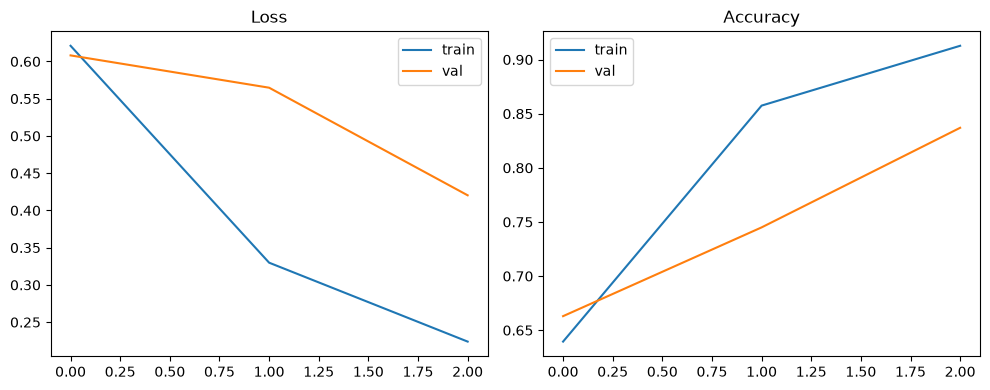

In [12]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


## Оценка и диагностика

Перед сдачей здесь должны одновременно выполняться все условия:
- `test_acc >= 0.75` на текущем subset;
- показан хотя бы один декодированный review;
- heatmap строится по первым содержательным токенам, а не по padded хвосту.

Сначала проверьте итоговую метрику, затем разберите один review и только после этого интерпретируйте attention trace.


In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'test_loss = {test_loss:.4f}')
print(f'test_acc  = {test_acc:.4f}')


test_loss = 0.3910
test_acc  = 0.8460


In [14]:
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {index + 3: word for word, index in word_index.items()}
reverse_word_index[0] = '[PAD]'
reverse_word_index[1] = '[START]'
reverse_word_index[2] = '[OOV]'
reverse_word_index[3] = '[UNUSED]'


def decode_review(token_ids):
    """Преобразует последовательность идентификаторов в список токенов.

    Аргументы:
      token_ids: Последовательность целочисленных идентификаторов токенов.

    Возвращает:
      Список строковых токенов в исходном порядке.

    Исключения:
      ValueError: Если входной список отсутствует.
    """
    if token_ids is None:
        raise ValueError('Ожидается непустой список идентификаторов токенов.')
    return [reverse_word_index.get(int(token), f'#{int(token)}') for token in token_ids]


sample_probs = model.predict(X_test[:32], verbose=0).ravel()
sample_index = int(np.argmax(np.abs(sample_probs - 0.5)))
sample_tokens = X_test[sample_index:sample_index + 1]
sample_target = y_test[sample_index]
sample_prob = float(model.predict(sample_tokens, verbose=0)[0, 0])

active_len = int(np.count_nonzero(sample_tokens[0]))
decoded_tokens = decode_review(sample_tokens[0][: min(active_len, 30)])

print('sample_index   :', sample_index)
print('true_label     :', int(sample_target))
print('predicted_prob :', round(sample_prob, 4))
print('decoded tokens :')
print(decoded_tokens)


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 4s 3us/step
sample_index   : 15
true_label     : 0
predicted_prob : 0.0002
decoded tokens :
['was', 'horrible', 'the', 'movie', 'was', 'utterly', 'boring', 'looked', 'like', 'the', 'shadow', 'with', 'alec', 'baldwin', 'the', 'shadow', 'is', 'infinitely', 'better', 'than', 'this', 'as', 'well', 'the', 'character', 'eve', 'was', 'so', 'undeveloped', 'and']


In [17]:
# TODO 4.1: получить attention_scores через tracing-path/model
sample_attention = attention_model.predict(sample_tokens, verbose=0)
# TODO 4.2: усреднить attention по головам
mean_attention = tf.reduce_mean(sample_attention, axis=1).numpy()[0]
# TODO 4.3: обрезать визуализацию до непустого фрагмента review
vis_len = min(active_len, 30) 
mean_attention = mean_attention[:vis_len, :vis_len]

visible_tokens = [reverse_word_index.get(int(tok), f'#{tok}') for tok in sample_tokens[0][:vis_len]]



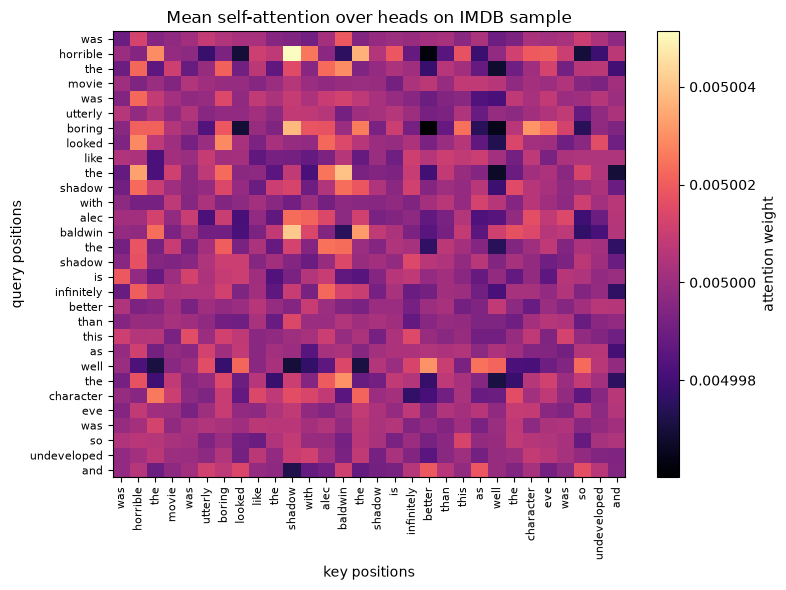

In [18]:
plt.figure(figsize=(8, 6))
plt.imshow(mean_attention, cmap='magma', aspect='auto')
plt.colorbar(label='attention weight')
plt.xticks(range(vis_len), visible_tokens, rotation=90, fontsize=8)
plt.yticks(range(vis_len), visible_tokens, fontsize=8)
plt.xlabel('key positions')
plt.ylabel('query positions')
plt.title('Mean self-attention over heads on IMDB sample')
plt.tight_layout()
plt.show()


## Если не получилось с первого раза

Сначала проверяйте не “Transformer ли плохой”, а:
- размер subset;
- длину `maxlen`;
- mask;
- classifier head;
- decode review для attention-визуализации.


## Если застряли: порядок диагностики

1. Проверить форму `X_train` и `y_train`.
2. Проверить `PAD = 0` и построение `padding_mask`.
3. Проверить shape после embedding и encoder block.
4. Проверить train/validation curves.
5. Проверить attention trace на одном review.


## Чек-лист перед сдачей

- `IMDB` загружен с ограничением словаря.
- После padding вход имеет форму `(N, T)`.
- Reuse-block из `ЛР01` используется как готовый блок, а не переписывается заново.
- Pooling учитывает mask.
- Есть итоговая оценка на test.
- `test_acc >= 0.75` на текущем subset.
- Есть хотя бы один декодированный review.
- Есть attention-визуализация по первым содержательным токенам review.


## Как использовать решение без самообмана

Неправильный путь:
- сразу открыть solution;
- скопировать reuse-block;
- получить working notebook без понимания, что именно вы перенесли из `ЛР01`.

Правильный путь:
- сначала собрать свою transfer-версию;
- потом свериться с walkthrough;
- потом пройти debugging playbook;
- сделать вторую попытку;
- и только после этого сравнить решение по блокам.


## Опционально после сдачи: мини-экзамен

1. Почему encoder-only Transformer уже подходит для `many-to-one` classification?
2. Зачем reuse toy-блока полезен методически?
3. Почему attention-карту review лучше показывать только на непустом фрагменте?
4. Как mask участвует и во внимании, и в pooling?


## Опционально после сдачи: что дальше

Этот notebook закрывает первую версию блока `03-Transformer`.

После него логично двигаться в одну из двух сторон:
- decoder-only Transformer и causal mask;
- полный encoder-decoder Transformer.

То есть теперь внимание уже не надстройка над RNN, а главный строительный блок модели.


## Опционально после сдачи: вопросы для самопроверки

## Типичные ошибки (симптом -> причина -> исправление)

- Обучение идёт слишком медленно -> слишком большой subset или `maxlen` -> вернуться к CPU-friendly конфигу.
- Accuracy слабая и нестабильная -> classifier head или mask собраны неверно -> проверить pooling и loss.
- Attention heatmap нечитаема -> показывается padded хвост или слишком длинный review -> обрезать до осмысленного фрагмента.
- Review декодируется странно -> не учтён offset словаря `IMDB` -> проверить `reverse_word_index`.
